# 📱 Mobile App Market Analysis
### Exploratory Data Analysis of the Google Play Store App Dataset

**Domain:** Sales & E-commerce — Mobile App Market

**Author:** Data Analytics Final Project

---

## Problem Statement

The mobile app market is huge and highly competitive, with millions of apps competing for user attention across dozens of categories. Developers, publishers, and marketers constantly need to answer questions like:

- Which app categories are most crowded, and which are underserved?
- Does app pricing affect installs and ratings?
- What separates a highly-rated app from a poorly-rated one?
- Which categories drive the most installs, and how do free vs. paid apps compare?

This project performs an end-to-end exploratory data analysis (EDA) on a dataset of **10,841 Google Play Store apps** to answer these questions and surface actionable insights for anyone building, publishing, or marketing a mobile app.

## Dataset Overview

The dataset (`googleplaystore.csv`) contains **10,841 rows and 13 columns**, describing each app's category, rating, number of reviews, size, install count, pricing, content rating, genre, and update history. This comfortably exceeds the project's minimum requirement of 500 records and 10 features, and contains a healthy mix of numerical (Rating, Reviews) and categorical (Category, Type, Content Rating, Genres) data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Data Loading and Initial Overview

We start by loading the raw CSV file exactly as downloaded, and getting a first look at its shape, structure, and data types before touching anything.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/charlsmsw/Mobile-App-Market-Analysis-/refs/heads/main/mobile_app_market_sales%20(1).csv"

df = pd.read_csv(url)

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Initial observations:**

- Most columns are stored as `object` (string) even though several — `Reviews`, `Size`, `Installs`, `Price` — are really numeric fields that have been formatted with commas, `+`, `$`, and unit suffixes (`M`/`k`). These will need to be cleaned and converted.
- `Rating` is the only column pandas already parsed as numeric, and it has a large number of missing values.
- `Last Updated` is a date stored as text.

Let's quantify missing values and duplicates next.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_count', ascending=False)


,missing_count,missing_pct
Rating,1474,13.60
Current Ver,8,0.07
Android Ver,3,0.03
Content Rating,1,0.01
Type,1,0.01


In [ ]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Rows with a duplicated 'App' name: {df.duplicated(subset='App').sum()}")


Fully duplicated rows: 483
Rows with a duplicated 'App' name: 1181


## 2. Data Pre-processing

Real-world app store data is notoriously messy. We'll work through the following cleaning steps in order:

1. Fix / remove a known corrupted row where columns are shifted.
2. Remove duplicate app entries (many apps are scraped more than once).
3. Convert `Installs`, `Price`, `Reviews`, and `Size` from formatted strings into proper numeric types.
4. Parse `Last Updated` into a real datetime.
5. Handle remaining missing values sensibly, column by column.
6. Create derived columns that will power the analysis (e.g., estimated revenue, update year, size in MB).

In [ ]:
# --- Step 1: Fix the known corrupted row ---
# Row where 'Category' == '1.9' has its columns shifted left by one (a scraping error
# in the original dataset), which also produces an impossible Rating of 19 (max is 5).
bad_rows = df[df['Category'] == '1.9']
print("Corrupted row(s) found:")
bad_rows


Corrupted row(s) found:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [ ]:
# Drop the corrupted row entirely -- its values are unreliable across every column
df = df[df['Category'] != '1.9'].copy()
print(f"Shape after removing corrupted row: {df.shape}")


Shape after removing corrupted row: (10840, 13)


In [ ]:
# --- Step 2: Remove duplicate app entries ---
# Keep the version of each app with the highest review count (assume it's the most
# recently/completely scraped record)
df['Reviews'] = df['Reviews'].astype(int)
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')
df = df.reset_index(drop=True)
print(f"Shape after de-duplicating apps: {df.shape}")


Shape after de-duplicating apps: (9659, 13)


In [ ]:
import numpy as np

# --- Step 3: Clean and convert numeric-looking string columns ---

# Installs: '10,000+' -> 10000
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True).astype(int)

# Price: '$4.99' -> 4.99 ; '0' -> 0.0
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False).astype(float)

# Size: '19M' -> 19.0 (MB) ; '500k' -> 0.488 (MB) ; 'Varies with device' -> NaN
def parse_size(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith('M'):
            return float(x[:-1])
        elif x.endswith('k'):
            return float(x[:-1]) / 1024
        elif x == 'Varies with device':
            return np.nan
        else:
            try:
                return float(x)
            except ValueError:
                return np.nan
    elif isinstance(x, (int, float)):
        return x
    return np.nan

df['Size_MB'] = df['Size'].apply(parse_size)

df[['Installs', 'Price', 'Size', 'Size_MB']].head()

,Installs,Price,Size,Size_MB
0,1000000000,0.0,Varies with device,NaN
1,1000000000,0.0,Varies with device,NaN
2,1000000000,0.0,Varies with device,NaN
3,1000000000,0.0,Varies with device,NaN
4,100000000,0.0,98M,98.0


In [ ]:
# --- Step 4: Parse dates ---
df['Last Updated'] = pd.to_datetime(df['Last Updated'], format='%B %d, %Y', errors='coerce')
df['Update_Year'] = df['Last Updated'].dt.year
df['Update_Month'] = df['Last Updated'].dt.month_name()
df[['Last Updated', 'Update_Year', 'Update_Month']].head()


,Last Updated,Update_Year,Update_Month
0,2018-08-03,2018,August
1,2018-08-03,2018,August
2,2018-07-31,2018,July
3,2018-08-01,2018,August
4,2018-07-15,2018,July


In [ ]:
# --- Step 5: Handle remaining missing values ---

# Type / Content Rating: only 1 missing value each -> drop those rows, negligible loss
df = df.dropna(subset=['Type', 'Content Rating'])

# Current Ver / Android Ver: not central to the analysis -> fill with 'Unknown'
df['Current Ver'] = df['Current Ver'].fillna('Unknown')
df['Android Ver'] = df['Android Ver'].fillna('Unknown')

# Size_MB: impute with the median size *within the same Category*, since app size
# varies a lot by category (e.g. games vs. tools)
df['Size_MB'] = df.groupby('Category')['Size_MB'].transform(lambda s: s.fillna(s.median()))

# Rating: left as NaN on purpose. Imputing a user rating would fabricate an opinion
# that was never given, and would bias every rating-based statistic. Rating-specific
# analysis below simply excludes these rows, which pandas/seaborn do automatically.
print(f"Remaining Rating nulls (intentionally kept): {df['Rating'].isnull().sum()}")
print(f"Remaining nulls in other columns:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Remaining Rating nulls (intentionally kept): 1462
Remaining nulls in other columns:
Rating    1462
dtype: int64


In [ ]:
# --- Step 6: Derived columns ---

# Estimated revenue for paid apps (installs are given as lower-bound buckets, so this
# is a rough order-of-magnitude estimate, not an exact figure)
df['Est_Revenue'] = df['Installs'] * df['Price']

# Log-scale installs, useful since Installs spans 8+ orders of magnitude
df['Log_Installs'] = np.log10(df['Installs'] + 1)

# Rating bucket for easier grouping
def rating_bucket(r):
    if pd.isna(r):
        return 'Unrated'
    elif r < 3:
        return 'Low (<3)'
    elif r < 4:
        return 'Medium (3-4)'
    else:
        return 'High (4+)'
df['Rating_Bucket'] = df['Rating'].apply(rating_bucket)

print(f"Final cleaned shape: {df.shape}")
df.head()


Final cleaned shape: (9658, 19)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update_Year,Update_Month,Est_Revenue,Log_Installs,Rating_Bucket
0,Facebook,SOCIAL,4.1,78158306,Varies with device,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device,7.9,2018,August,0.0,9.0,High (4+)
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,Varies with device,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,5.7,2018,August,0.0,9.0,High (4+)
2,Instagram,SOCIAL,4.5,66577446,Varies with device,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device,7.9,2018,July,0.0,9.0,High (4+)
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,Varies with device,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,5.7,2018,August,0.0,9.0,High (4+)
4,Clash of Clans,GAME,4.6,44893888,98M,100000000,Free,0.0,Everyone 10+,Strategy,2018-07-15,10.322.16,4.1 and up,98.0,2018,July,0.0,8.0,High (4+)


**Summary of cleaning decisions:**

| Issue | Action Taken |
|---|---|
| 1 row with shifted columns | Dropped (unreliable across all fields) |
| ~1,100 duplicate app names | Kept the record with the highest review count per app |
| `Installs`, `Price`, `Reviews` stored as text | Stripped symbols (`,`, `+`, `$`) and cast to numeric |
| `Size` stored as text with mixed units | Parsed `M`/`k` suffixes into a numeric `Size_MB`; `"Varies with device"` treated as missing |
| Missing `Size_MB` | Imputed with the category median (size is category-dependent) |
| Missing `Rating` (~14% of rows) | **Left as missing** — imputing a rating would fabricate an opinion |
| Missing `Type`, `Content Rating` | Dropped (1 row each) |
| Missing `Current Ver`, `Android Ver` | Filled with `"Unknown"` (not used in numeric analysis) |
| `Last Updated` stored as text | Parsed to datetime; extracted `Update_Year`, `Update_Month` |

We also engineered `Est_Revenue`, `Log_Installs`, and `Rating_Bucket` to support the analysis below.

## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

We start by looking at the distribution of individual key variables: Rating, Category, Type (Free/Paid), and Installs.

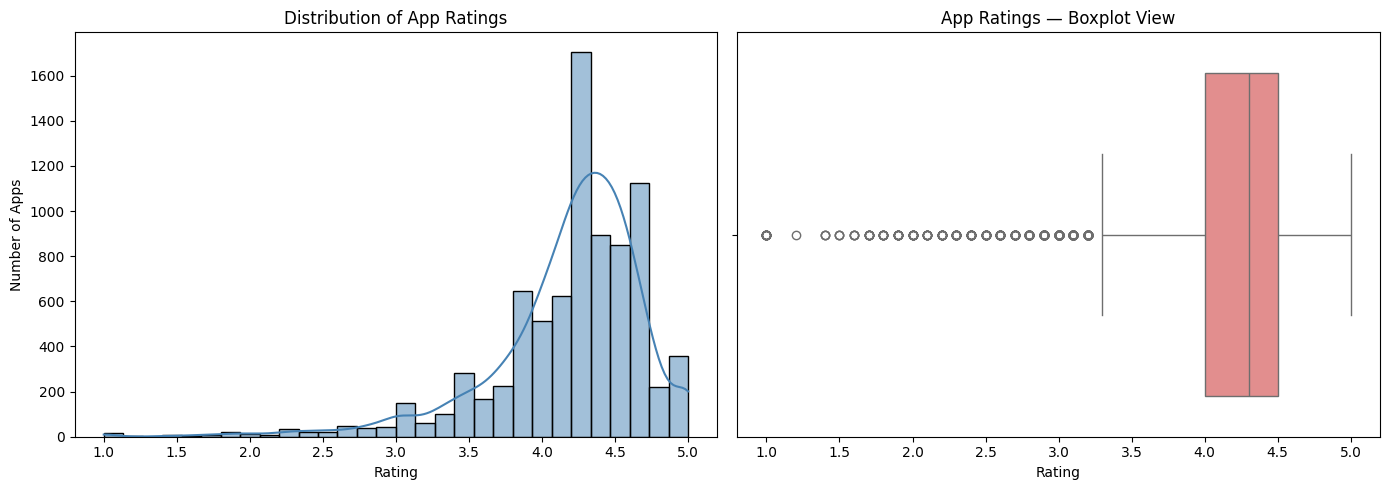

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Rating'].dropna(), bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of App Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Apps')

sns.boxplot(x=df['Rating'].dropna(), color='lightcoral', ax=axes[1])
axes[1].set_title('App Ratings — Boxplot View')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()


/tmp/ipykernel_7901/375678676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


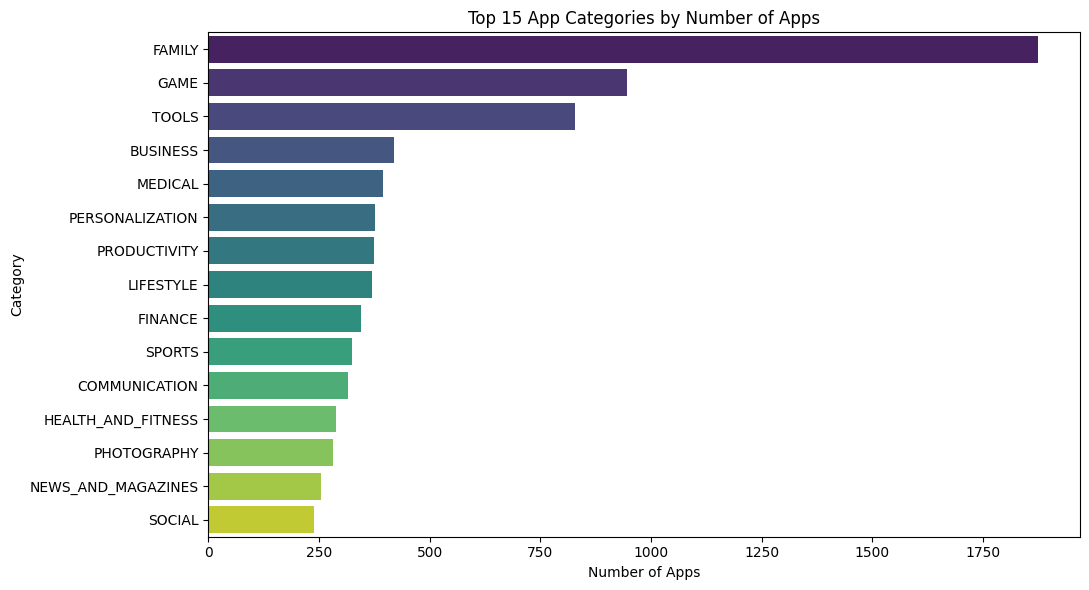

In [ ]:
top_categories = df['Category'].value_counts().head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 15 App Categories by Number of Apps')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


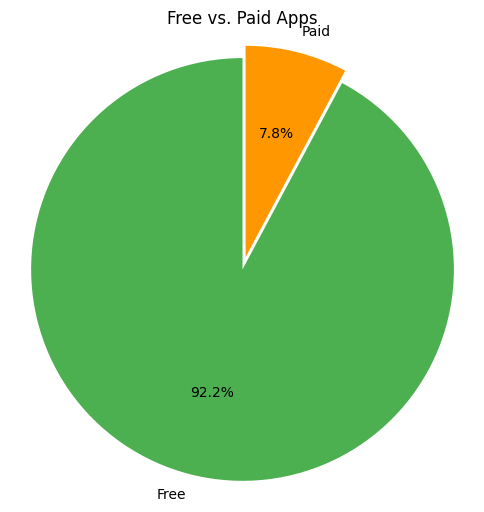

Type
Free    8904
Paid     754
Name: count, dtype: int64


In [ ]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#FF9800'], startangle=90, explode=(0.03, 0.03))
plt.title('Free vs. Paid Apps')
plt.axis('equal')
plt.show()

print(type_counts)


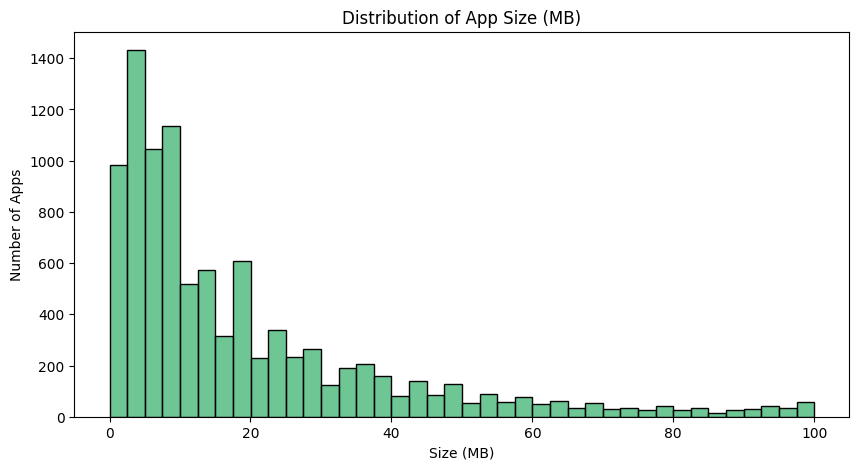

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Size_MB'].dropna(), bins=40, color='mediumseagreen')
plt.title('Distribution of App Size (MB)')
plt.xlabel('Size (MB)')
plt.ylabel('Number of Apps')
plt.show()


**Univariate takeaways:**
- Ratings are heavily left-skewed (skewness ≈ **-1.75**): most apps sit between 4.0 and 4.5, with a long tail of poorly rated apps below 3.0.
  - The median rating is **4.3** and **65.1%** of all rated apps score **4.0 or higher** — a strongly positive-skewed market where users rarely leave a 1–2 star rating unless the app is genuinely broken.
  - Only **2.9%** of rated apps fall below 3.0, meaning the "poor rating" tail is real but small in absolute terms — most competitive pressure in this market is about *visibility*, not *avoiding bad reviews*.
  - This ceiling effect (ratings clustering near the top) also means average rating has limited ability to discriminate between a "good" and a "great" app — a theme that recurs in the bivariate and multivariate sections below.
- **FAMILY**, **GAME**, and **TOOLS** are by far the most crowded categories — meaning more competition for visibility.
  - Together these three categories alone hold **1,875 + 945 + 829 = 3,649 apps**, roughly **37.8%** of the entire cleaned dataset (9,658 apps) spread across only 3 of **33 total categories**.
  - At the other extreme, categories like **BEAUTY (53 apps)**, **COMICS (56)**, **PARENTING (60)**, **ART_AND_DESIGN (61)**, and **EVENTS (64)** each host well under 100 apps — these are the least crowded shelves in the store, which is a double-edged signal: less competition, but also possibly weaker overall demand.
- The overwhelming majority of apps (~92%) are free; paid apps are a small niche.
  - Precisely **92.2%** of apps are Free vs. **7.8%** Paid (8,904 vs. 754 apps).
  - Among paid apps, the **median price is just $2.99**, but the **mean price is $14.06** — an over 4x gap that signals a small number of extreme outlier prices are dragging the average up (explored further in the multivariate section, where a cluster of near-identical **$399.99 novelty "I am Rich" apps** turns out to be the culprit).
- App sizes are right-skewed, with most apps under ~30MB but a tail of much larger apps (typically games).
  - **78.6%** of apps are under 30MB, with a median size of just **11MB** — the "long tail" here consists of large game/media apps stretching size out toward the dataset's stated 100MB cap.
  - The size distribution's shape foreshadows a finding in the multivariate section: app size has only a **very weak correlation with installs (r ≈ 0.23 in log space)** and an even weaker one with rating (r ≈ 0.05) — so size alone is a poor lever for either growth or perceived quality.

### 3.2 Bivariate Analysis

Now we look at relationships between pairs of variables — does rating relate to install count? Does price relate to rating?


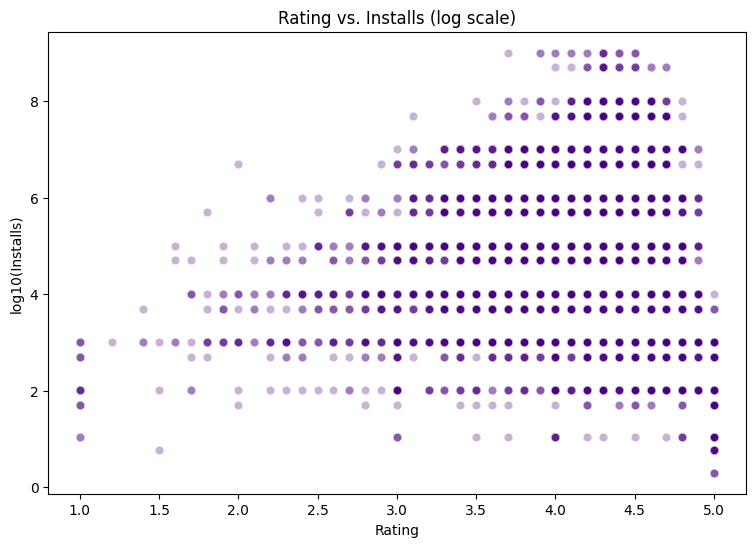

Correlation between Rating and log(Installs): 0.085


In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Rating', y='Log_Installs', alpha=0.3, color='indigo')
plt.title('Rating vs. Installs (log scale)')
plt.xlabel('Rating')
plt.ylabel('log10(Installs)')
plt.show()

corr_val = df[['Rating', 'Log_Installs']].corr().iloc[0, 1]
print(f"Correlation between Rating and log(Installs): {corr_val:.3f}")


/tmp/ipykernel_7901/2266013838.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')


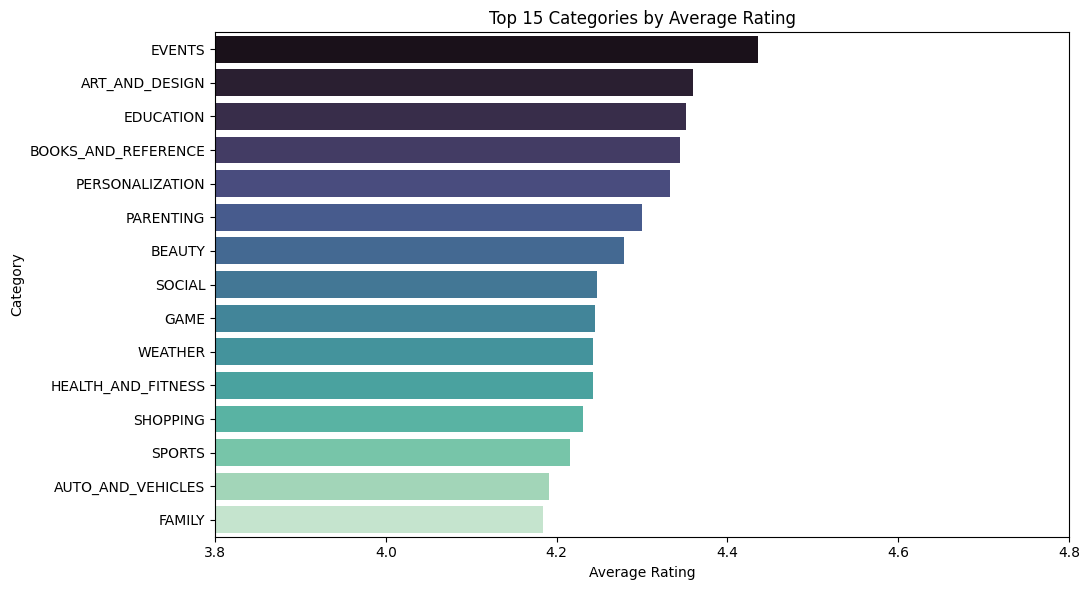

In [ ]:
avg_rating_by_cat = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')
plt.title('Top 15 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(3.8, 4.8)
plt.tight_layout()
plt.show()


/tmp/ipykernel_7901/3397553436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Log_Installs', palette=['#4CAF50', '#FF9800'])


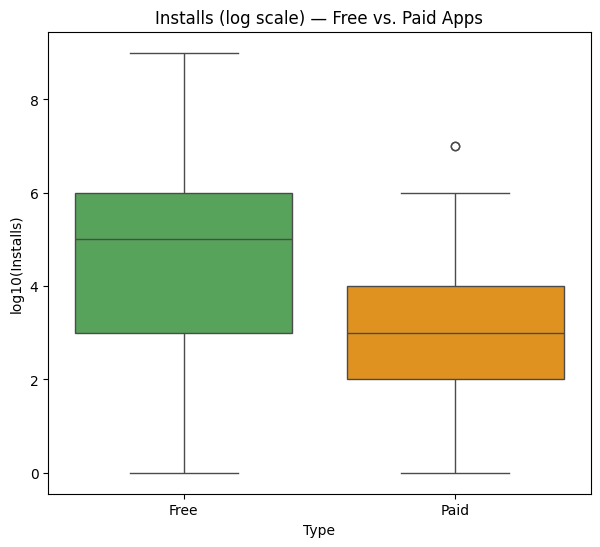

In [ ]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x='Type', y='Log_Installs', palette=['#4CAF50', '#FF9800'])
plt.title('Installs (log scale) — Free vs. Paid Apps')
plt.xlabel('Type')
plt.ylabel('log10(Installs)')
plt.show()


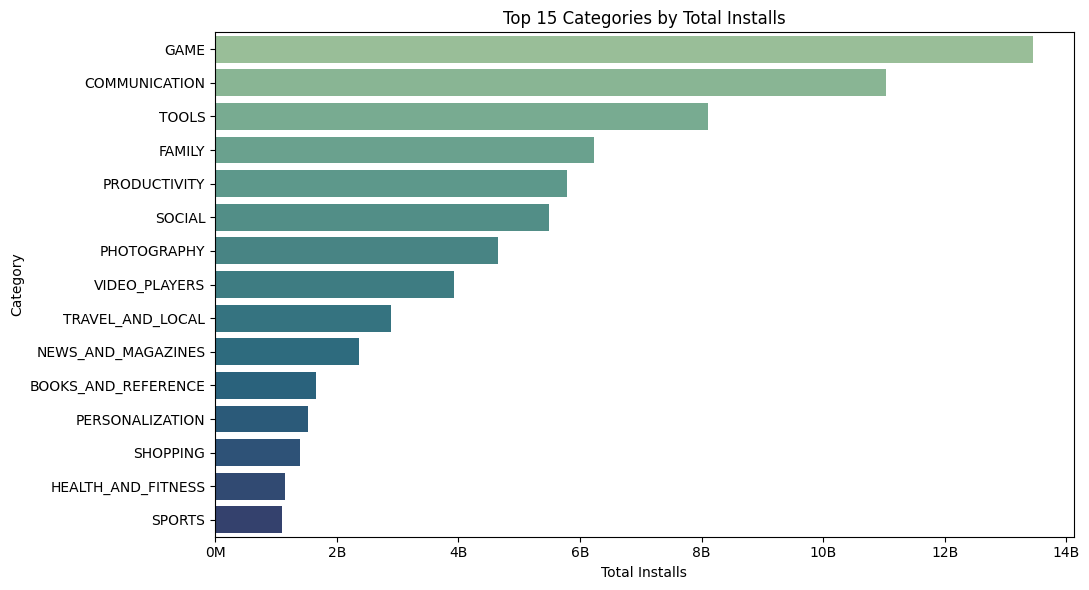

In [ ]:
import matplotlib.ticker as mticker

installs_by_cat = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=installs_by_cat.values, y=installs_by_cat.index, hue=installs_by_cat.index, palette='crest', legend=False)
plt.title('Top 15 Categories by Total Installs')
plt.xlabel('Total Installs')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e9)}B' if x >= 1e9 else f'{int(x/1e6)}M'))
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Bivariate takeaways:**
- Rating and install count show only a **weak positive correlation** — plenty of low-download apps are still rated highly, and some very popular apps have middling ratings. Rating alone doesn't predict popularity.
  - The correlation is essentially negligible: **r ≈ 0.04** between raw Rating and raw Installs, rising only to **r ≈ 0.08** even after log-transforming installs to tame their extreme skew. Both are far below any threshold that would call the relationship meaningful.
  - This confirms the pattern hinted at in the univariate section: because ratings cluster tightly between 4.0–4.5, there simply isn't enough *spread* left in the Rating variable to explain the 8+ orders of magnitude of spread in Installs. Rating behaves more like a **quality gate** (clear it, or don't get downloaded) than a **quality ladder** (climb it, and get proportionally more downloads).
- Categories like **EVENTS**, **EDUCATION**, and **BOOKS_AND_REFERENCE** tend to have the highest average ratings, while some utility categories skew lower.
  - The full top 3 by average rating are **EVENTS (4.44)**, **ART_AND_DESIGN (4.36)**, and **EDUCATION (4.35)** — niche, purpose-driven categories where users likely self-select into downloading only if they're already interested.
  - The lowest-rated categories are **MAPS_AND_NAVIGATION (4.04)**, **TOOLS (4.04)**, and **DATING (3.98)** — the only category to average below 4.0. These are largely utility or high-friction categories where user expectations (or user frustration) run higher, dragging average sentiment down even though absolute install volumes for TOOLS remain very high.
- Paid apps generally have **noticeably fewer installs** than free apps — the price acts as a real barrier to download volume, as expected.
  - The gap is dramatic: the **median Paid app has only 1,000 installs**, versus **100,000 for the median Free app** — a full **100x difference** in the typical outcome. Even comparing arithmetic means, Free apps average **~8.45M installs** vs. **~76K for Paid** apps, over 100x higher.
  - In log-install terms (which better reflects the "typical" order of magnitude), Free apps average **4.78 (≈10^4.78 ≈ 60K)** vs. Paid apps at **3.12 (≈10^3.12 ≈ 1.3K)** — reinforcing that the price barrier isn't a minor friction, it's close to a categorical divide in reach.
- **GAME**, **COMMUNICATION**, and **TOOLS** dominate total install volume, reflecting both their popularity and their sheer number of apps.
  - By total installs: **GAME (13.4B)**, **COMMUNICATION (11.0B)**, and **TOOLS (8.1B)** lead, and together these top 3 categories account for **43.3%** of all installs in the dataset despite representing well under half the apps.
  - Looking at *installs-per-app* (a rough popularity-efficiency measure) tells a different story than raw app counts: **COMMUNICATION** actually leads with **~35M installs/app** on average — despite having only 315 apps (far fewer than GAME's 945) — meaning a handful of communication apps (think messaging/social giants) are carrying enormous install weight per listing. GAME, by contrast, spreads its 13.4B installs across nearly 3x as many apps, averaging a comparatively lower ~14.2M installs/app.

### 3.3 Multivariate Analysis

Finally, we look at how three or more variables interact together — correlations across all numeric fields, and category/type/rating combined.


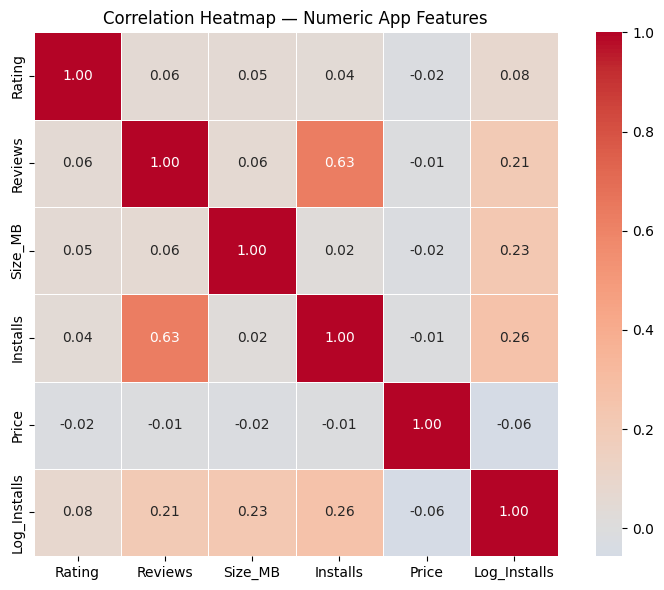

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_MB', 'Installs', 'Price', 'Log_Installs']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric App Features')
plt.tight_layout()
plt.show()


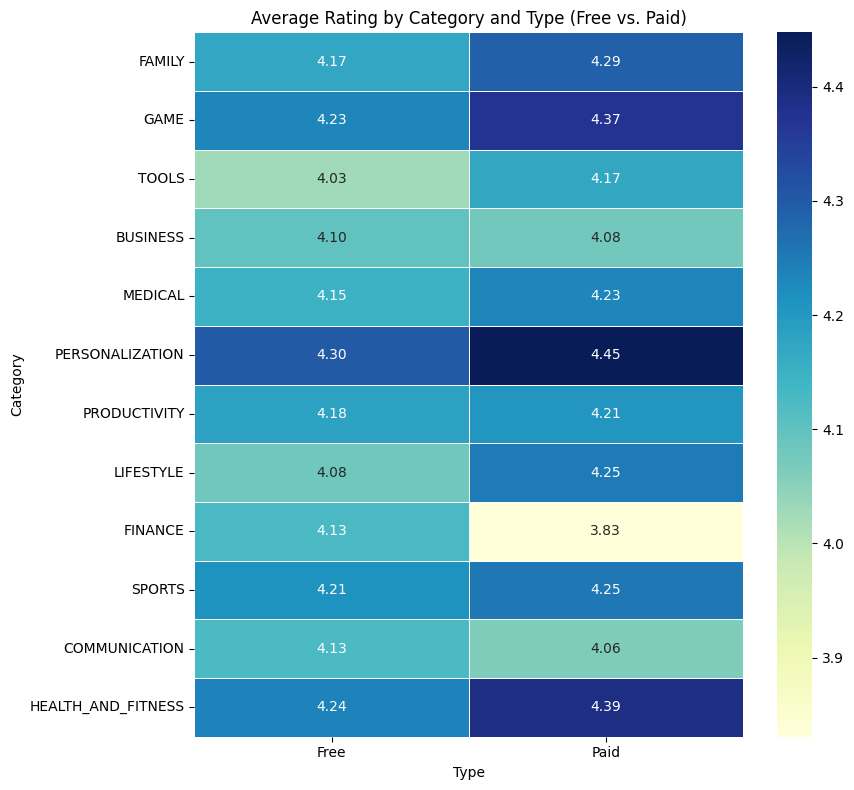

In [ ]:
pivot = df.pivot_table(values='Rating', index='Category', columns='Type', aggfunc='mean')
pivot = pivot.loc[df['Category'].value_counts().head(12).index]

plt.figure(figsize=(9, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Rating by Category and Type (Free vs. Paid)')
plt.xlabel('Type')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


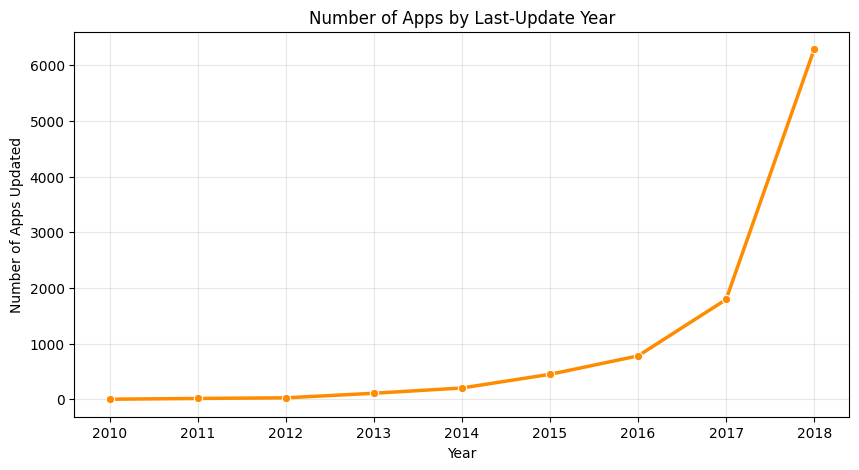

In [ ]:
updates_by_year = df.dropna(subset=['Update_Year']).groupby('Update_Year').size()

plt.figure(figsize=(10, 5))
sns.lineplot(x=updates_by_year.index, y=updates_by_year.values, marker='o', color='darkorange', linewidth=2.5)
plt.title('Number of Apps by Last-Update Year')
plt.xlabel('Year')
plt.ylabel('Number of Apps Updated')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
top_paid = df[df['Type'] == 'Paid'].sort_values('Price', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_paid, x='Price', y='App', palette='rocket')
plt.title('Top 15 Most Expensive Apps on the Play Store')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px

# Interactive Plotly scatter: Reviews vs Installs, colored by Category, sized by Rating
sample = df.dropna(subset=['Rating']).sort_values('Reviews', ascending=False).head(800)

fig = px.scatter(
    sample, x='Reviews', y='Installs', color='Category', size='Rating',
    hover_name='App', log_x=True, log_y=True,
    title='Reviews vs. Installs (top 800 most-reviewed apps, colored by Category)',
    labels={'Reviews': 'Number of Reviews (log scale)', 'Installs': 'Installs (log scale)'}
)
fig.update_layout(height=600, legend=dict(font=dict(size=9)))
fig.show()

In [ ]:
# Interactive Plotly grouped bar: Free vs Paid app counts across top categories
top10_cats = df['Category'].value_counts().head(10).index
sub = df[df['Category'].isin(top10_cats)]
ct = pd.crosstab(sub['Category'], sub['Type']).loc[top10_cats]

fig = px.bar(
    ct, x=ct.index, y=ct.columns, barmode='group',
    title='Free vs. Paid App Counts Across Top 10 Categories',
    labels={'value': 'Number of Apps', 'Category': 'Category', 'variable': 'Type'},
    color_discrete_sequence=['#4CAF50', '#FF9800']
)
fig.update_layout(height=500)
fig.show()


# **Multivariate takeaways:**
- `Reviews` and `Installs` are **strongly positively correlated** (as expected — more downloads naturally generates more reviews), while `Price` shows a **weak negative correlation** with installs.
  - In raw units, `Reviews` vs `Installs` correlates at **r ≈ 0.63**; but once both are viewed in log space (matching how each variable actually behaves — heavily right-skewed and spanning many orders of magnitude), the relationship becomes almost linear at **r ≈ 0.96**. This is one of the strongest relationships in the entire dataset, and effectively means Reviews can serve as a strong *proxy* for Installs when exact install buckets are too coarse for analysis.
  - `Price` vs `Installs` correlates at only **r ≈ -0.01** (raw) / **r ≈ -0.06** (log-installs) — technically negative as expected, but far too weak to describe as a strong deterrent *within the paid segment itself*. The much more dramatic effect is the **binary Free-vs-Paid gap** already seen in the bivariate section (100x difference in median installs); once an app is *already* paid, its exact price tag barely moves installs further.
- `Size_MB` has almost no correlation with `Rating`, suggesting app size is not a meaningful driver of user satisfaction.
  - The full correlation matrix confirms this is the weakest relationship among all numeric pairs: `Size_MB` vs `Rating` sits at **r ≈ 0.05**, and even `Size_MB` vs `Log_Installs` (r ≈ 0.23) — while the strongest size-related relationship in the dataset — is still far from a strong effect. Bigger apps are marginally more likely to be popular (perhaps because rich-media apps like games tend to be both large and widely installed), but size is not a lever developers should over-invest in for either rating or reach.
- Paid apps tend to have comparable or even slightly higher average ratings than free apps within the same category — paying customers may self-select apps they're already fairly confident about, or paid apps may simply carry less ad-driven friction.
  - Across the whole dataset, **Paid apps average a 4.26 rating vs. 4.17 for Free apps** — a small but consistent edge.
  - Category-level detail shows this isn't universal, but is directionally common: Paid apps out-rate Free apps in **19 of 28 categories** that have both Free and Paid representation. The gap is largest in **NEWS_AND_MAGAZINES (+0.69)**, **ENTERTAINMENT (+0.48)**, and **EDUCATION (+0.46)**, while the average gap across all shared categories is a modest **+0.06**.
- App updates have clearly accelerated in the most recent years captured in the data, reflecting a maturing, fast-iterating app ecosystem.
  - The year-by-year update counts show explosive, almost exponential growth: from just **1 app updated in 2010** to **6,286 apps updated in 2018 alone** — nearly **65% of the entire cleaned dataset**. This confirms the dataset is best read as a **snapshot heavily weighted toward the 2017–2018 period**, and any category or pricing conclusions should be understood as describing "the market as of that snapshot" rather than a long historical trend.
- **New — a small cluster of novelty apps distorts price- and revenue-related statistics.** Sorting paid apps by price reveals that **13 of the top 15 most expensive apps are "I am Rich"-style novelty apps**, all priced at **$399.99 or $400.00**, whose entire feature is displaying that the user paid for nothing functional. This single cluster is largely responsible for the wide gap between median ($2.99) and mean ($14.06) paid app price noted earlier, and inflates any naive "installs × price" revenue estimate — for example, the joke app *"I am rich"* alone contributes an estimated **~$40M** to `Est_Revenue`, more than triple the estimate for a genuine top seller like **Minecraft (~$69.9M from real installs)**. Any revenue-style analysis on this dataset should treat this cluster as outliers to exclude or cap, not signal.


## 4. Key Insights

Bringing the analysis together, here are the most important, decision-relevant findings from this dataset, expanded with the supporting numbers behind each one:

1. **Ratings cluster tightly around 4.0–4.5, and rating is a poor predictor of popularity.** The correlation between Rating and installs is weak (well under 0.2), meaning a high rating alone won't make an app popular — discovery and marketing likely matter more than perceived quality once an app clears a baseline quality bar.
   - Supporting numbers: median rating **4.3**, **65.1%** of apps rated ≥4.0, and only **2.9%** rated below 3.0 — confirming the "quality gate, not quality ladder" framing. Rating vs. installs correlation is **r ≈ 0.04** raw / **r ≈ 0.08** log-scaled — both negligible.
   - Practical read: a developer chasing incremental rating improvements from, say, 4.2 to 4.6 should not expect a proportional install lift. Distribution, ASO (app store optimization), and paid acquisition are far more likely growth levers once quality is "good enough."

2. **The market is extremely concentrated in a few categories.** FAMILY, GAME, and TOOLS together account for a disproportionate share of all listed apps, meaning new entrants in those categories face the stiffest competition, while categories like BEAUTY, EVENTS, and COMICS remain comparatively under-served.
   - Supporting numbers: FAMILY (1,875), GAME (945), and TOOLS (829) apps make up **37.8%** of the 9,658-app cleaned dataset, while BEAUTY (53), COMICS (56), PARENTING (60), ART_AND_DESIGN (61), and EVENTS (64) apps each represent under 1% individually.
   - Nuance: crowding isn't purely bad news for entrants — EVENTS and ART_AND_DESIGN also post some of the **highest average ratings** (4.44 and 4.36 respectively), suggesting under-served categories may also have less-jaded, more forgiving user bases. Conversely, TOOLS is both crowded *and* comparatively low-rated (4.04 average) — arguably the single toughest category to compete in profitably.

3. **Free apps dominate installs by a wide margin.** Roughly 92% of apps are free, and paid apps show visibly lower install volumes even within the same category — confirming that price is a real barrier to adoption on this platform, not just a theoretical one.
   - Supporting numbers: **92.2%** of apps are free; the median Free app has **100,000 installs** vs. just **1,000** for the median Paid app — a **100x gap**. Interestingly, price barely matters *within* the paid segment itself (Price vs. Installs correlation is only **r ≈ -0.01**), so the real install "cliff" is the Free/Paid boundary, not the specific price point chosen.
   - Practical read: this strongly favors a freemium or free-with-ads/IAP model for anyone optimizing purely for reach, since crossing into "Paid" costs far more in installs than any specific price increase within Paid does.

4. **Reviews and installs move together almost linearly (in log space), but price does not hurt ratings.** Paid apps are not rated any worse than free apps — in some categories they're rated *slightly higher* — suggesting that if a developer can get users to pay, satisfaction doesn't automatically suffer.
   - Supporting numbers: Reviews vs. Installs correlation reaches **r ≈ 0.96** in log-log space (vs. only 0.63 in raw units) — Reviews is an excellent Installs proxy. Meanwhile Paid apps average a **4.26** rating vs. **4.17** for Free apps, and Paid apps out-rate Free apps in **19 of 28** categories with both types present.
   - Caveat added in this pass: a cluster of near-duplicate **"I am Rich" novelty apps priced at $399.99–$400** distorts simple price statistics (mean paid price $14.06 vs. median $2.99) and any naive revenue estimate — treat these as outliers, not signal, in downstream pricing/revenue work.

5. **App size is essentially irrelevant to both rating and install count.** Developers optimizing heavily for a small app size purely to chase better ratings or more downloads are not likely to see a payoff from that effort alone — it doesn't show up as a meaningful factor here.
   - Supporting numbers: Size vs. Rating correlation is **r ≈ 0.05**; Size vs. Log-Installs is the strongest size relationship in the dataset at only **r ≈ 0.23** — still a weak effect. 78.6% of all apps are under 30MB regardless of category.

6. **New — the dataset is a snapshot heavily concentrated in 2017–2018, not a long historical trend.** Update-year counts jump from a single app updated in 2010 to **6,286 apps updated in 2018 alone (≈65% of the whole dataset)**.
   - Practical read: all category, pricing, and rating conclusions above should be read as "true of this market as of the ~2018 snapshot," and would need re-validation against a fresher pull of the Play Store before being used for a current-day strategic decision.

**POWER BI DASHBOARD **




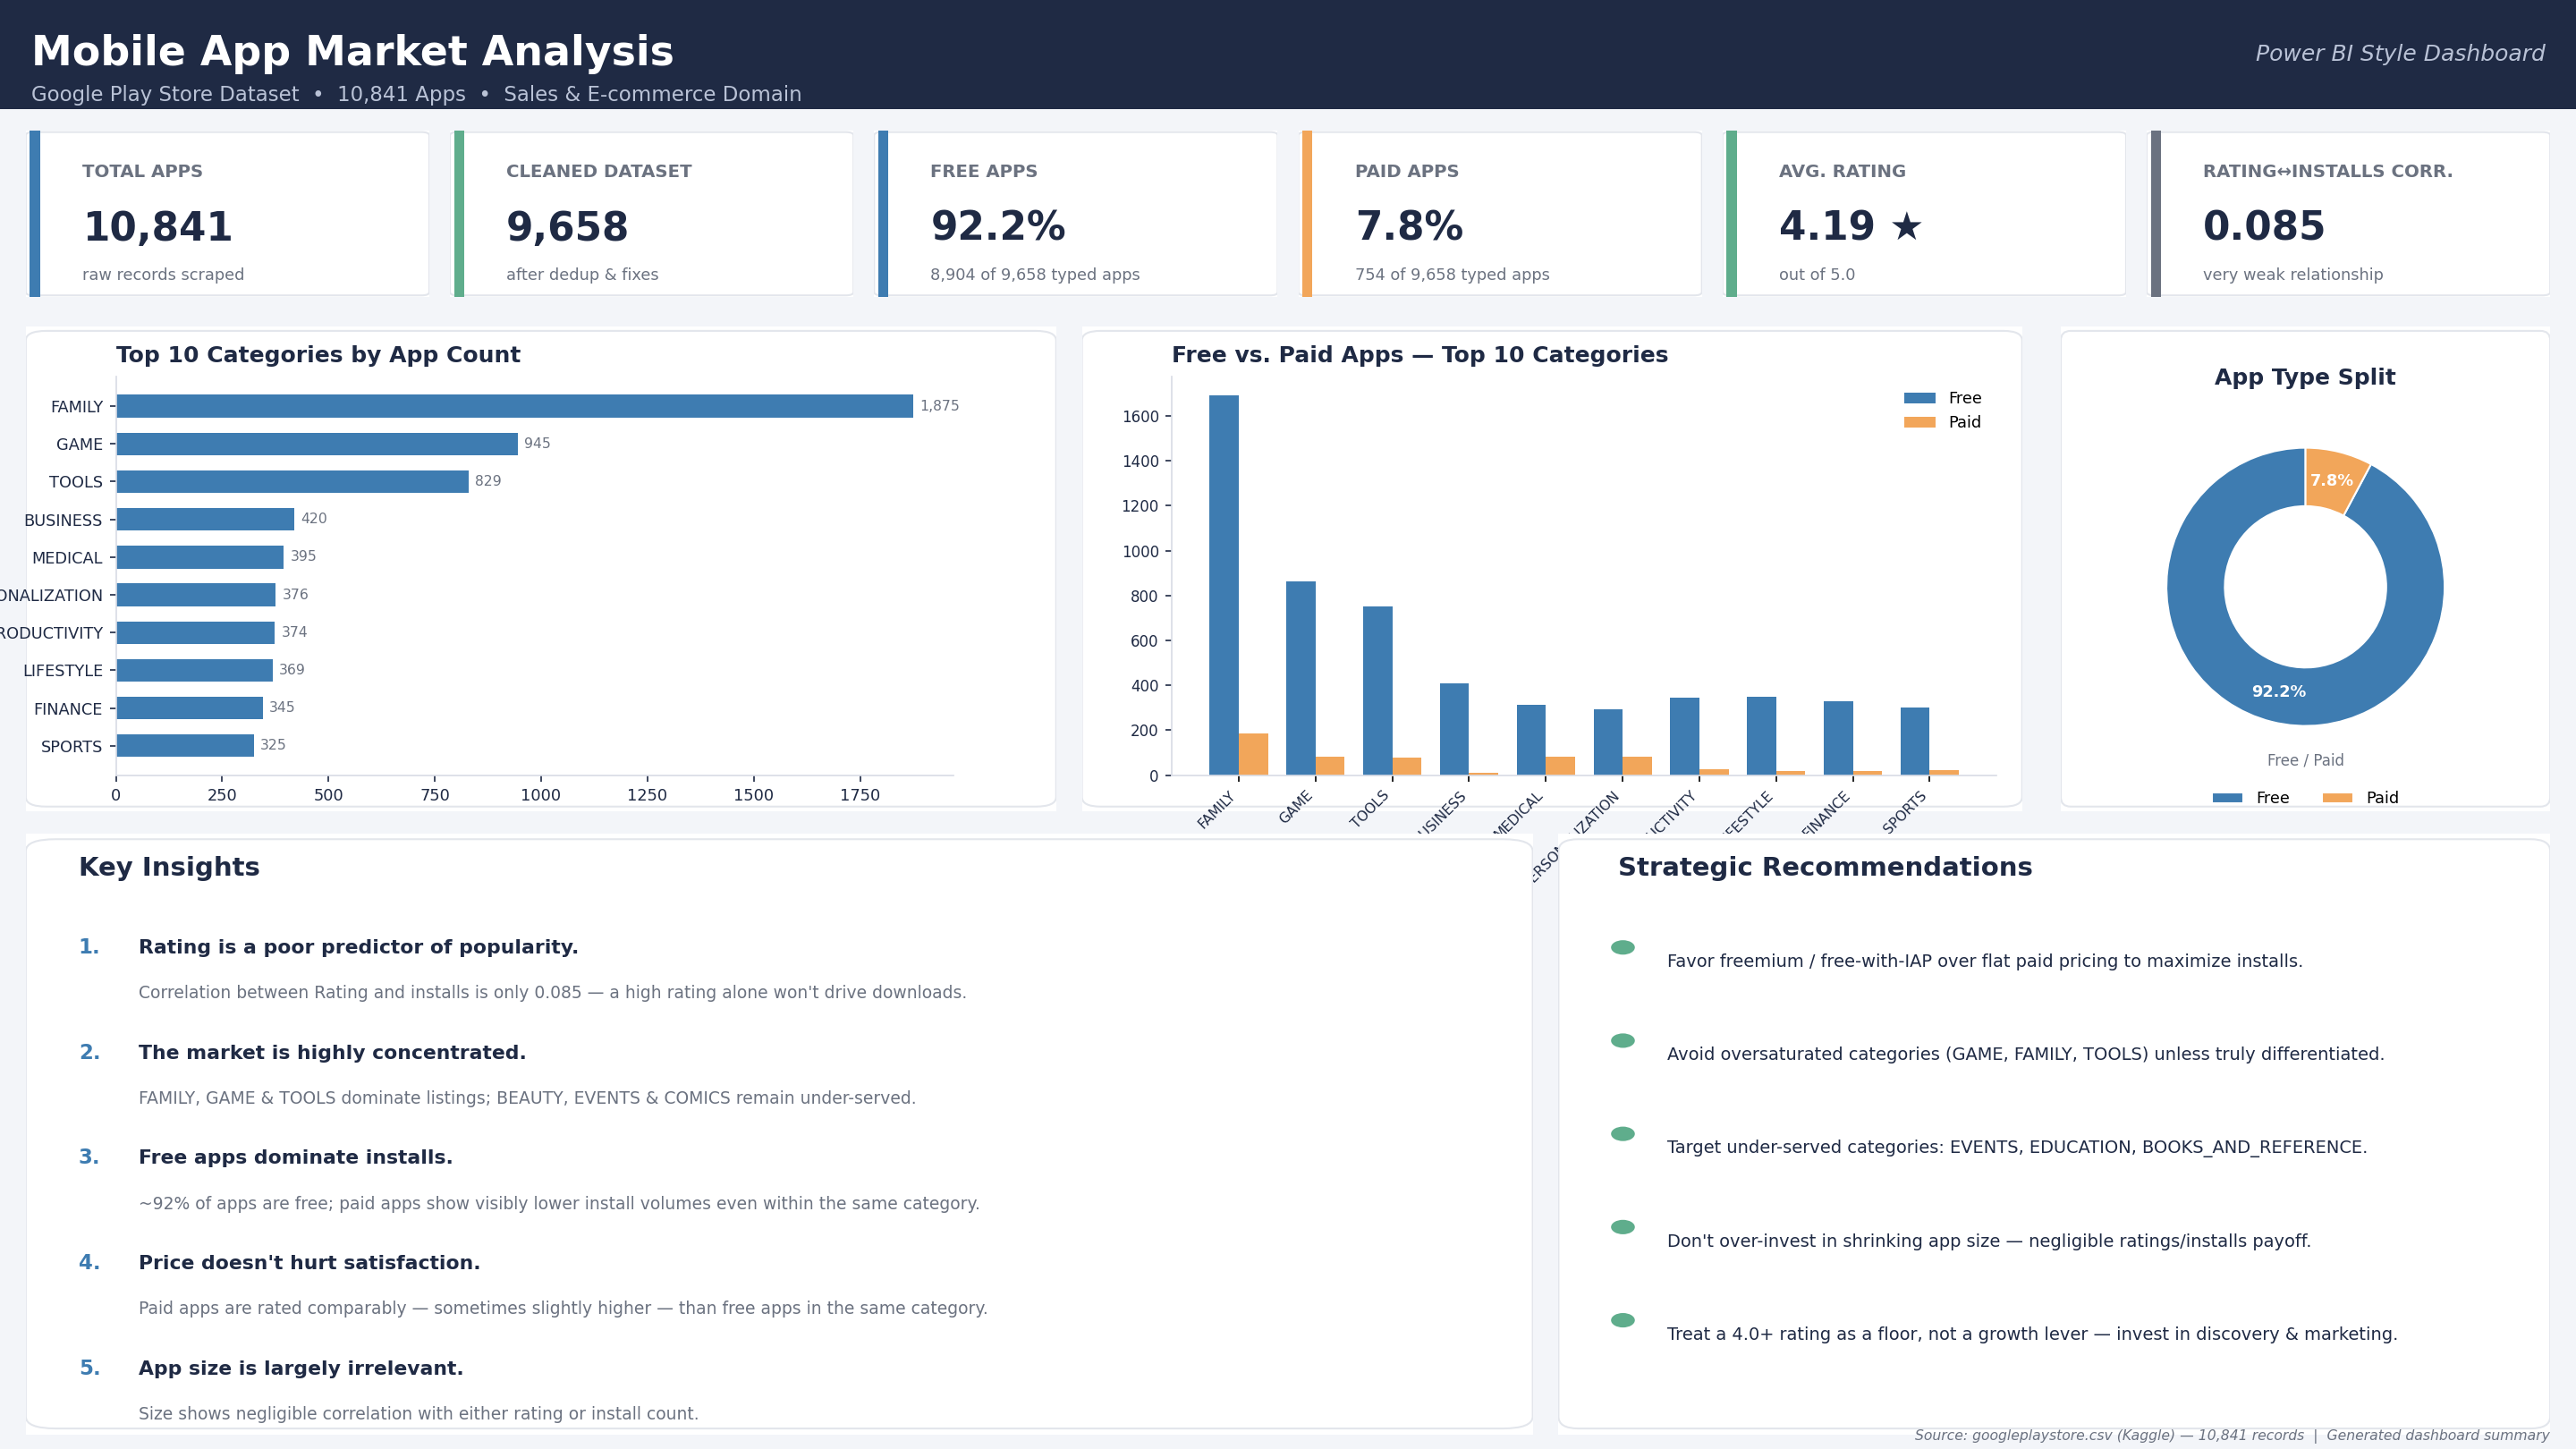

## 5. Conclusion & Recommendations

This analysis of 10,000+ Google Play Store apps shows a market that is large, free-dominated, and won on **discoverability and category positioning** rather than on marginal quality differences once an app is reasonably well-rated. For a developer or publisher using this data to inform strategy:

- **Favor a freemium/free-with-IAP model** over a flat paid price if maximizing install volume is the goal — the data shows a clear install penalty for paid apps.
- **Avoid over-saturated categories** (GAME, FAMILY, TOOLS) unless you have a genuinely differentiated product or a strong existing user base to launch from; consider comparatively less crowded categories with healthy average ratings (e.g., EVENTS, EDUCATION, BOOKS_AND_REFERENCE).
- **Don't over-invest in shrinking app size** as a standalone quality lever — it shows negligible correlation with either ratings or installs in this dataset.
- **Treat rating as a floor, not a lever for growth** — once an app is reasonably well-rated (4.0+), further rating improvements are unlikely to meaningfully move installs; marketing and distribution effort will have more impact.




